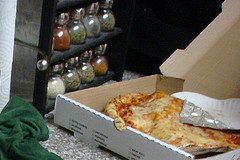

In [ ]:
from PIL import Image
import re

Action_tokens = {
    "region_x": "<|x_0|>,<|x_1|>,<|x_2|>,<|x_3|>,<|x_4|>,<|x_5|>,<|x_6|>,<|x_7|>".split(","),
    "region_y": "<|y_0|>,<|y_1|>,<|y_2|>,<|y_3|>,<|y_4|>,<|y_5|>,<|y_6|>,<|y_7|>".split(","),
    "dino": "<|detection_action_start|>",
    "clip": "<|clip_action_start|>",
    "sam": "<|seg_action_start|>",
}

def from_region_tokens_to_region(region_tokens):
    match_tokens_x, match_tokens_y = region_tokens
    x_indices = [int(item.replace("<|x_","").replace("|>","")) for item in match_tokens_x]
    y_indices = [int(item.replace("<|y_","").replace("|>","")) for item in match_tokens_y]
    minx = min(x_indices)
    miny = min(y_indices)
    maxx = max(x_indices)
    maxy = max(y_indices)
    region = [(minx, miny), (maxx, maxy)]
    return region

def region_token_to_new_image_path(found_region_tokens, meta_item, num_cut=8):
    regions = from_region_tokens_to_region(found_region_tokens)
    max_x = max([x for x,y in regions])
    min_x = min([x for x,y in regions])
    max_y = max([y for x,y in regions])
    min_y = min([y for x,y in regions])

    max_x = min(max_x+1, num_cut-1)
    min_x = max(min_x-1, 0)
    max_y = min(max_y+1, num_cut-1)
    min_y = max(min_y-1, 0)
    image_path = meta_item["images"][0]
    image = Image.open(image_path)
    width, height = image.size
    st_w = 0
    st_h = 0

    grid_width = width / num_cut
    grid_height = height / num_cut

    new_x_min = st_w + (min_x ) * grid_width
    new_y_min = st_h + (min_y ) * grid_height
    new_x_max = st_w + (max_x + 1) * grid_width
    new_y_max = st_h + (max_y + 1) * grid_height

    new_bbox = (new_x_min, new_y_min, new_x_max, new_y_max)
    bbox_subfix = f"_{int(new_bbox[0])},{int(new_bbox[1])},{int(new_bbox[2])},{int(new_bbox[3])}"

    new_image_path = image_path + bbox_subfix
    return new_image_path

def generate_region_item(gt_item, ls_found_region_tokens, num_cut=8):

    ls_new_image_path = [region_token_to_new_image_path(found_region_tokens, gt_item, num_cut=num_cut) for found_region_tokens in ls_found_region_tokens]
    
    if len(ls_new_image_path) == 1:
        new_image_prompt = "<image>"
    else:
        new_image_prompt = ""
        for i in range(len(ls_new_image_path)):
            new_image_prompt += f"Region {i}: <image>\n"
    return ls_new_image_path, new_image_prompt

def check_region_tokens(text):

    pattern = re.compile(r'<\|region_token_start\|>(<\|[xy]_[01234567]\|>)+<\|region_token_end\|>')
    matches = pattern.finditer(text)

    found_tokens = []
    for match in matches:
        match_str = match.group()
        # match_str = match_str.replace("<|region_token_start|>","").replace("<|region_token_end|>","")
        match_tokens_x = [token for token in Action_tokens["region_x"] if token in match_str]
        match_tokens_y = [token for token in Action_tokens["region_y"] if token in match_str]
        found_tokens.append((match_tokens_x, match_tokens_y))

    if found_tokens:
        return found_tokens, True
    else:
        return None, False
cot = "<|region_token_start|><|x_0|><|y_2|><|x_5|><|y_7|><|region_token_end|>"
cot = "<|region_token_start|><|x_3|><|y_6|><|x_6|><|y_7|><|region_token_end|>"
cot = "<|region_token_start|><|x_0|><|y_1|><|x_2|><|y_7|><|region_token_end|>"
cot = "<|region_token_start|><|x_0|><|y_1|><|x_7|><|y_7|><|region_token_end|>"
cot="<|region_token_start|><|x_4|><|y_0|><|x_7|><|y_2|><|region_token_end|>"
cot = "<|region_token_start|><|x_5|><|y_0|><|x_7|><|y_1|><|region_token_end|>"
cot = "<|region_token_start|><|x_7|><|y_0|><|x_7|><|y_2|><|region_token_end|>\n<|region_token_start|><|x_2|><|y_3|><|x_3|><|y_4|><|region_token_end|>"
# cot="<|region_token_start|><|x_5|><|y_0|><|x_6|><|y_0|><|region_token_end|>"
item = {
    "images": [
        # "/data/spatialRGPT_qa/images/00000000/3a88f275daee0020/8.png"
        # "/data/dataset-spatial-reasoning/VSR/data/images/000000440650.jpg"
        # "/data/dataset-spatial-reasoning/VSR/data/images/000000320379.jpg"
        # "/data/dataset-spatial-reasoning/VSR/data/images/000000302514.jpg"
    #   "/data/dataset-spatial-reasoning/VSR/data/images/000000365139.jpg",
      "/mnt/tidal-alsh01/usr/liangxun/data/dataset-spatial-reasoning/Qspatial/QSpatial_plus/images/025.png"
        ],
    # "images": ["/data/spatialRGPT_qa/images/00000000/3b31d5a6507ca16d/8.png"],
    "cot": cot
    
}

ls_found_region_tokens, do_region = check_region_tokens(item["cot"])
ls_new_image_path, new_image_prompt = generate_region_item(item, ls_found_region_tokens , num_cut=8)

image = ls_new_image_path[0]
if "_" in image.rsplit(".")[-1]:
    image, crop_position = image.rsplit("_", 1)
    crop_position = tuple(map(int, crop_position.split(",")))
else:
    image = image
    crop_position = None
image = Image.open(image)
if crop_position is not None:
    image = image.crop(crop_position)
image.show()